In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('ushape.csv')

In [47]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


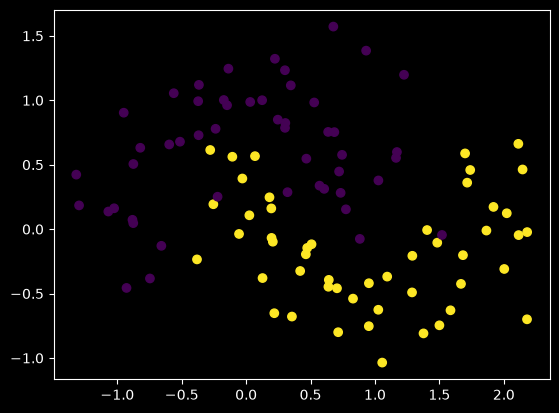

In [48]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [49]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [50]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [51]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/mnt/c/Users/vinay kumar/Desktop/Deep-Learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.get_weights()

[array([[ 0.56301486, -0.969998  ,  2.0694542 , -0.642348  , -0.5481442 ,
         -0.17534156,  1.0606711 ,  1.5700337 ,  1.0111377 ,  1.1410254 ],
        [ 0.3996778 ,  1.2524266 , -1.1987906 , -0.9779033 , -0.161983  ,
          0.20612581, -0.0785095 ,  0.6236939 , -0.5303031 , -1.895848  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.32481998,  0.34366396,  0.58959067,  0.10127862, -0.02519951,
         -0.46092483,  0.30920562, -0.23316711,  0.48600686,  0.6047243 ],
        [ 0.32805926,  0.9416501 ,  0.4424622 ,  0.1827972 ,  0.31997904,
         -0.5466691 , -0.86497146, -0.93177354, -0.19854553,  0.10823603],
        [ 0.29476336, -0.68454754,  0.5903261 ,  0.54182494,  0.42717937,
         -0.7570916 , -0.45164052,  0.78413147, -0.22527695, -0.36488372],
        [-0.09278839, -0.40116745,  0.14154884,  0.17877091, -0.31472063,
         -0.19973622,  0.68234843,  0.17313606, -0.10175692,  0.11420612],
        [ 0.19391

In [53]:
initial_weights = model.get_weights()

In [54]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [55]:
model.set_weights(initial_weights)

In [56]:
model.get_weights()

[array([[-1.1547532 ,  0.8994958 , -0.07768551,  0.03988972, -0.22721899,
         -1.4581248 ,  0.06183955,  1.2914771 , -0.39686862, -0.221688  ],
        [ 0.69802517, -0.80517083,  0.3660342 , -0.78833294, -0.22573285,
         -0.25000203, -0.01373222, -0.61790556, -0.8787018 ,  0.3296988 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.06224703, -0.09927712, -0.3887374 , -0.0108807 ,  0.1879432 ,
          0.03873504,  0.24196315,  0.07484567, -0.3989488 ,  0.0476724 ],
        [-0.07821218,  0.07530188, -0.081879  , -0.26210803, -0.19934048,
         -0.24078225, -0.10556865, -0.33473653, -0.25385478,  0.07122746],
        [ 0.29408532,  0.31145787, -0.05942536,  0.41817024,  0.46887234,
         -0.02851379,  0.5670763 , -0.00573063, -0.28051627,  0.36537108],
        [ 0.2824502 ,  0.54006517,  0.27764878,  0.0898189 , -0.643597  ,
          0.01374251,  0.12746082,  0.20933932, -0.25072327, -0.308397  ],
        [ 0.20956

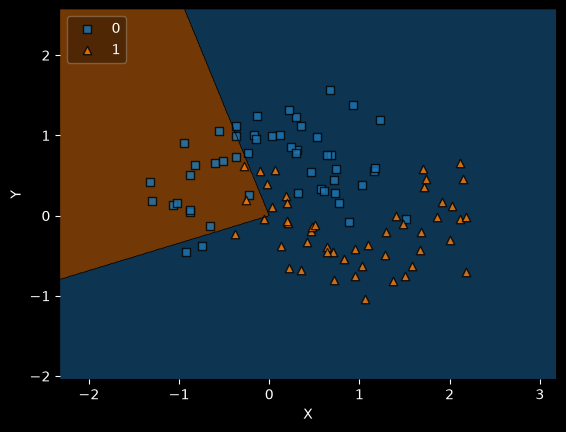

In [57]:
from mlxtend.plotting import plot_decision_regions

class MyClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X, verbose=0)
        return (y_pred >= 0.5).astype(int).ravel()

clf = MyClassifier(model)

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()